#Importing all libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


## import data

In [3]:
df=pd.read_csv('data/students.csv')

In [4]:
df.sample(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
14,female,group A,master's degree,standard,none,50,53,58
991,female,group B,some high school,standard,completed,65,82,78
744,male,group B,some college,free/reduced,none,55,55,47
180,male,group C,master's degree,free/reduced,completed,62,68,75
287,female,group B,some high school,standard,none,67,89,82


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [10]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [16]:
for col in df.columns:
        if df[col].dtype == 'object':
                print(f'The unique values of {col} : {df[col].unique()}')
                print('==='*20)

The unique values of gender : ['female' 'male']
The unique values of race/ethnicity : ['group B' 'group C' 'group A' 'group D' 'group E']
The unique values of parental level of education : ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
The unique values of lunch : ['standard' 'free/reduced']
The unique values of test preparation course : ['none' 'completed']


In [18]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

print("we have {} Numeric columns {}".format(len(numeric_cols), numeric_cols))
print(f'we have {len(categorical_cols)} Categorical columns: {categorical_cols}')

we have 3 Numeric columns Index(['math score', 'reading score', 'writing score'], dtype='object')
we have 5 Categorical columns: Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')


### Adding newTotal score and average score columns

In [21]:
df['Total_score'] = df['math score'] + df['reading score'] + df['writing score']
df['Average_score'] = df['Total_score'] / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


**Histogram**

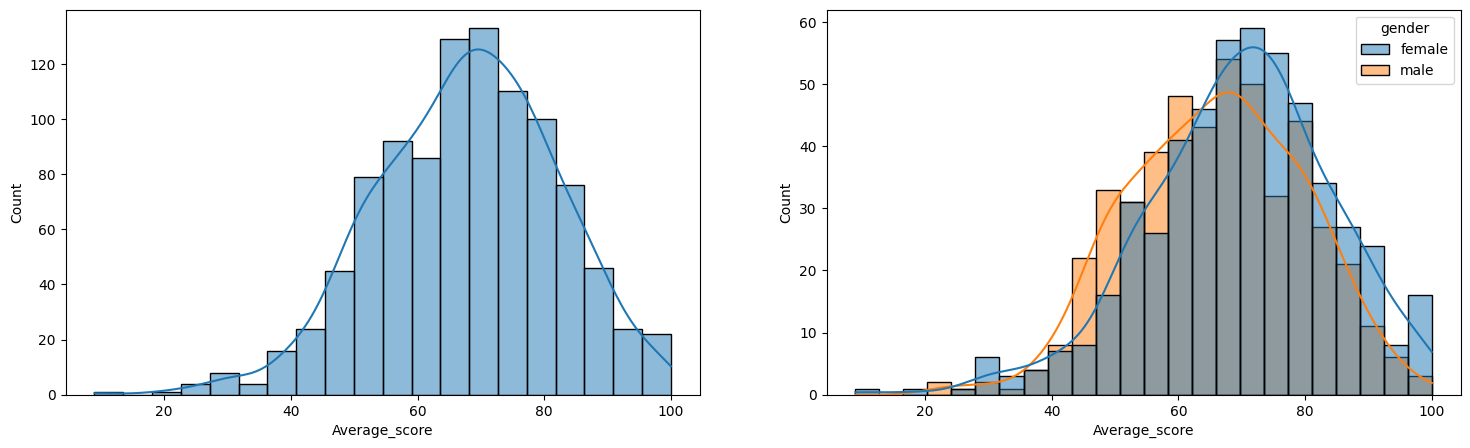

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df,x=df['Average_score'], bins=20, kde=True)

plt.subplot(1, 2, 2)
sns.histplot(data=df,x=df['Average_score'], kde=True,hue=df['gender'])
plt.show()